# Exercise 1: Descriptive statistics with Palmer Penguins

This exercise uses the Palmer Penguins dataset (`seaborn.load_dataset('penguins')`) and ties directly to the **M3-1: Statistical Analysis** learning outcomes. Work through the sections in order. Where you are asked for prose, use your own words in a short paragraph unless a bullet list is requested.

Dataset reference: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Meet the Palmer penguins

![](../assets/lter_penguins.png)

### Bill dimensions

The culmen is the upper ridge of a bird’s bill. In the simplified `penguins` data, culmen length and depth are renamed as variables `bill_length_mm` and `bill_depth_mm` to be more intuitive.

For this penguin data, the culmen (bill) length and depth are measured as shown below (thanks Kristen Gorman for clarifying!):

![](../assets/culmen_depth.png)

## A. Concepts: what statistics is and how we use data

**1.** For this dataset, what is a reasonable **population** you might want to learn about? What is the **sample** you actually have in `df`? (One or two sentences each.)

**2.** List every column in `df`. For each, label it **numerical** or **categorical** (if a column could be debated, say why).

**3.** Give **two new examples** of variables that are clearly numerical and **two** that are clearly categorical *not* in this table (any domain you like).


### Population and Sample

The **population** is the larger group we want to understand, which in this case is penguins like those represented in the Palmer Penguins dataset.

The **sample** is the set of penguins actually recorded in the dataset and used for the analysis.

In [15]:
df.columns


Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

### Variable Types

- `species` → categorical  
- `island` → categorical  
- `bill_length_mm` → numerical  
- `bill_depth_mm` → numerical  
- `flipper_length_mm` → numerical  
- `body_mass_g` → numerical  
- `sex` → categorical  

### Examples of Variable Types

**Numerical variables:**
- Temperature
- Salary

**Categorical variables:**
- Eye color
- Car brand

## B. Calculations on the sample: proportion, mean, variance

Use the cleaned numeric columns only where needed (drop rows with missing body mass or bill length, or use `.dropna(subset=[...])` as you prefer). Show your code and round printed numbers sensibly.

**1.** For the variable `body_mass_g`:

- Compute the **proportion** of penguins with body mass **greater than** the overall median body mass (among non-missing values).
- Compute the **mean** and **variance** of `body_mass_g` (same subset).

In [16]:
body_mass = df["body_mass_g"].dropna()

median_body_mass = body_mass.median()
proportion_gt_median = (body_mass > median_body_mass).mean()
mean_body_mass = body_mass.mean()
variance_body_mass = body_mass.var()

print("Median:", median_body_mass)
print("Proportion > median:", proportion_gt_median)
print("Mean:", mean_body_mass)
print("Variance:", variance_body_mass)

Median: 4050.0
Proportion > median: 0.4853801169590643
Mean: 4201.754385964912
Variance: 643131.0773267479


### Interpretation

We computed the median, the proportion of penguins with body mass greater than the median, the mean, and the variance.

The mean gives the average body mass, while the variance shows how spread out the body mass values are.

**2.** For `body_mass_g`, identify at least **two** distributional summary measures that describe **center** and **spread** (name them and compute them). Optionally add a third that describes **shape** (e.g. skewness), if you know how to compute it.

In [17]:
body_mass = df["body_mass_g"].dropna()

In [18]:
# center
mean_val = body_mass.mean()
median_val = body_mass.median()

# spread
std_val = body_mass.std()
iqr_val = body_mass.quantile(0.75) - body_mass.quantile(0.25)

print("Mean:", mean_val)
print("Median:", median_val)
print("Standard Deviation:", std_val)
print("IQR:", iqr_val)

Mean: 4201.754385964912
Median: 4050.0
Standard Deviation: 801.9545356980955
IQR: 1200.0


### Center and Spread

The two measures of **center** are the **mean** and the **median**.

The two measures of **spread** are the **standard deviation** and the **interquartile range (IQR)**.

The standard deviation describes the overall variation in the data, while the IQR focuses on the middle 50% of values.

## C. Shape of distributions: vocabulary and examples

**1.** Briefly define each shape in your own words: **normal (Gaussian)**, **uniform**, **skewed**, **exponential**.

**2.** Give **two real-world examples** of quantities that are *often modeled as* roughly normally distributed (they need not be perfect). (you can search the internet)

**3.** Give **one example** of data that is typically **not** normal—e.g. **exponential-like** or strongly skewed—and say why. (you can search the internet)

### 1. Definitions of distributions

- **Normal (Gaussian):**  
A symmetric distribution where most values are around the mean, and fewer values appear as we move away from the center.

- **Uniform:**  
A distribution where all values are equally likely across a range.

- **Skewed:**  
A distribution that is not symmetric and has a longer tail on one side.

- **Exponential:**  
A distribution where small values are common and larger values become increasingly rare.


### 2. Real-world examples of roughly normal distributions

- Human height  
- Exam scores in large groups


### 3. Example of non-normal data

Income distribution is usually skewed.  
Most people earn moderate incomes, while a small number of people earn very high incomes, creating a long right tail.

## D. Percentiles and the empirical rule (normal distribution)

Work on `body_mass_g` (non-missing) or `bill_length_mm`—pick one and stick to it for this section.

**1.** In plain language, explain what the **75th percentile** of body mass means for a penguin in this sample.
**2.** Compute the **25th, 50th, and 75th percentiles** for your chosen variable.

### 75th Percentile

The 75th percentile means that about 75% of the values are less than or equal to that number, and about 25% are greater than it.

Assume for **discussion** that flipper length (or another chosen numeric column) were **exactly** normal with the mean and standard deviation you observe in the sample.

**3.** For a normal distribution, explain what share of values fall within **1**, **2**, and **3 standard deviations** of the mean (the empirical rule). Then **compute** the interval $\mu \pm 1\sigma$, $\mu \pm 2\sigma$, and $\mu \pm 3\sigma$ using your sample $\mu$ and $\sigma$ for that variable.

In [20]:
body_mass = df["body_mass_g"].dropna()

q25 = body_mass.quantile(0.25)
q50 = body_mass.quantile(0.50)
q75 = body_mass.quantile(0.75)

print("25th percentile:", q25)
print("50th percentile (median):", q50)
print("75th percentile:", q75)

25th percentile: 3550.0
50th percentile (median): 4050.0
75th percentile: 4750.0


### Interpretation

These percentiles summarize the distribution of body mass.

The median is the middle value, while the 25th and 75th percentiles help describe the lower and upper parts of the distribution.

### Empirical Rule

For a normal distribution:

- About **68%** of values lie within **1 standard deviation** of the mean
- About **95%** lie within **2 standard deviations**
- About **99.7%** lie within **3 standard deviations**

In [21]:
flipper = df["flipper_length_mm"].dropna()

mu = flipper.mean()
sigma = flipper.std()

print("Mean:", mu)
print("Standard deviation:", sigma)
print("mu ± 1σ:", (mu - sigma, mu + sigma))
print("mu ± 2σ:", (mu - 2*sigma, mu + 2*sigma))
print("mu ± 3σ:", (mu - 3*sigma, mu + 3*sigma))

Mean: 200.91520467836258
Standard deviation: 14.061713679356886
mu ± 1σ: (np.float64(186.8534909990057), np.float64(214.97691835771948))
mu ± 2σ: (np.float64(172.79177731964882), np.float64(229.03863203707635))
mu ± 3σ: (np.float64(158.73006364029192), np.float64(243.10034571643325))


### Interpretation

These percentiles summarize the distribution of body mass.

The median is the middle value, while the 25th and 75th percentiles help describe the lower and upper parts of the distribution.

## E. Box plot: read the graphic

**1.** (SOLVED) Draw a **box plot** of `body_mass_g`, split by `species`.

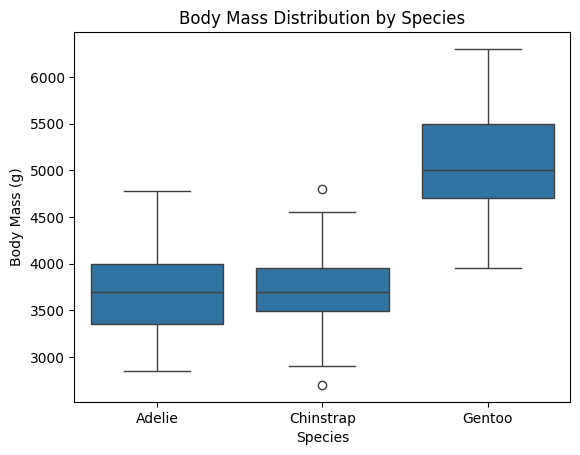

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

**2.** On your plot, **label or describe** what each part represents: median, quartiles, whiskers, and points outside the whiskers (if any). What does the box width tell you?

### Parts of a Box Plot

- The **line inside the box** is the median.
- The **bottom and top of the box** are the first quartile (Q1) and third quartile (Q3).
- The **box** contains the middle 50% of the data.
- The **whiskers** extend to values that are not considered extreme.
- Points outside the whiskers may be **outliers**.

**3.** Write **two** sentences about the sample using words like **“most”** and **“few”** (e.g. which species tend to be heavier). Base this only on what you see in the plot.

### Description Using “Most” and “Few”

Most Gentoo penguins have a higher body mass than most Adelie and Chinstrap penguins.

Few Adelie penguins reach the larger body mass values that are common among Gentoo penguins.

**4.** Write **one** quantitative claim about the data (e.g. “the median body mass of Chinstrap is above 3500 g”). Then **verify** it with code (`groupby`, `median`, etc.) and state whether your claim was **true or false**.

In [24]:
medians = df.groupby("species")["body_mass_g"].median()
print(medians)

species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64


### Quantitative Claim

The median body mass of Gentoo penguins is higher than the median body mass of the other two species.

The computed medians confirm this claim.


Use the cell below as a starting point: it prints **medians by species** and shows one example check (Chinstrap median vs 3500 g). Adapt the last lines to match *your* claim.


In [7]:
#| label: verify-median-example
import seaborn as sns

df_v = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

medians = df_v.groupby("species", observed=True)["body_mass_g"].median()
print("Median body mass (g) by species:")
print(medians)

# Example verification — replace with checks that match your own claim
chin_median = medians.get("Chinstrap")
print("\nExample claim: Chinstrap median > 3500 g")
print("  Chinstrap median:", chin_median)
print("  Claim is true:", chin_median > 3500)

Median body mass (g) by species:
species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64

Example claim: Chinstrap median > 3500 g
  Chinstrap median: 3700.0
  Claim is true: True


## F. Outliers

**1.** Name **two** methods for identifying or **removing outliers** on a numeric column. For each, give a **one-sentence** explanation of the rule. Then show **one** method applied in code to flag outliers in `bill_length_mm` (do not delete them from the full dataset the count or indices is enough).

### Methods for Detecting Outliers

Two common methods for identifying outliers are:

1. **IQR rule**  
2. **Z-score method**

In [25]:
bill = df["bill_length_mm"].dropna()

q1 = bill.quantile(0.25)
q3 = bill.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["bill_length_mm"] < lower_bound) | (df["bill_length_mm"] > upper_bound)]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print(outliers[["species", "bill_length_mm"]])

Q1: 39.225
Q3: 48.5
IQR: 9.274999999999999
Lower bound: 25.312500000000004
Upper bound: 62.412499999999994
Number of outliers: 0
Empty DataFrame
Columns: [species, bill_length_mm]
Index: []


### Interpretation

Using the IQR rule, we identified observations with unusually small or large bill lengths.

These values may be considered potential outliers compared with the rest of the sample.

## Summary

In this lab, we explored descriptive statistics using the Palmer Penguins dataset.

We identified variable types, calculated measures of center and spread, described distribution shapes, used percentiles and the empirical rule, interpreted box plots, and examined possible outliers.